In [1]:
!pip install torchvision torch torchaudio numpy matplotlib

In [2]:
import torchvision
import torchaudio
import matplotlib.pyplot as plt
import torchaudio.transforms as T
import torch
import os

### Exploration Partie I

In [3]:
data = torchvision.datasets.CIFAR10(download=True, root="./")
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

Récupération d'une image par label pour vérification

In [4]:
labels_check = [0 for i in range(10)]
images = [[] for i in range(10)]

for (image, label) in data:
    if labels_check[label] == 0:
        labels_check[label] = 1
        images[label] = image

Vérification de la distribution des classes dans CIFAR-10

<BarContainer object of 10 artists>

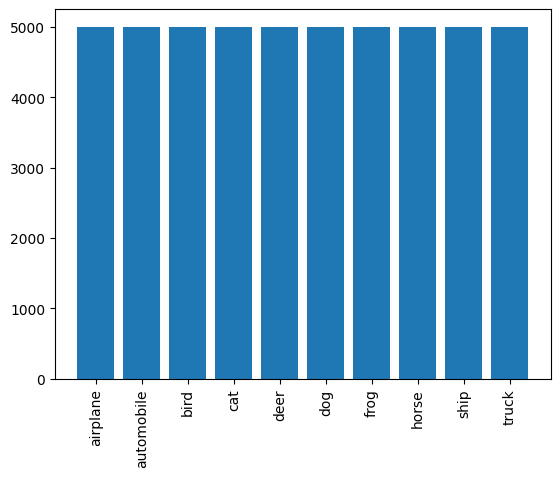

In [5]:
labels_count = [0 for i in range(10)]

for (image, label) in data:
    labels_count[label] +=1
    
plt.xticks(rotation=90)
plt.bar(labels, labels_count)

Affichage des images représentatives de chaque classe

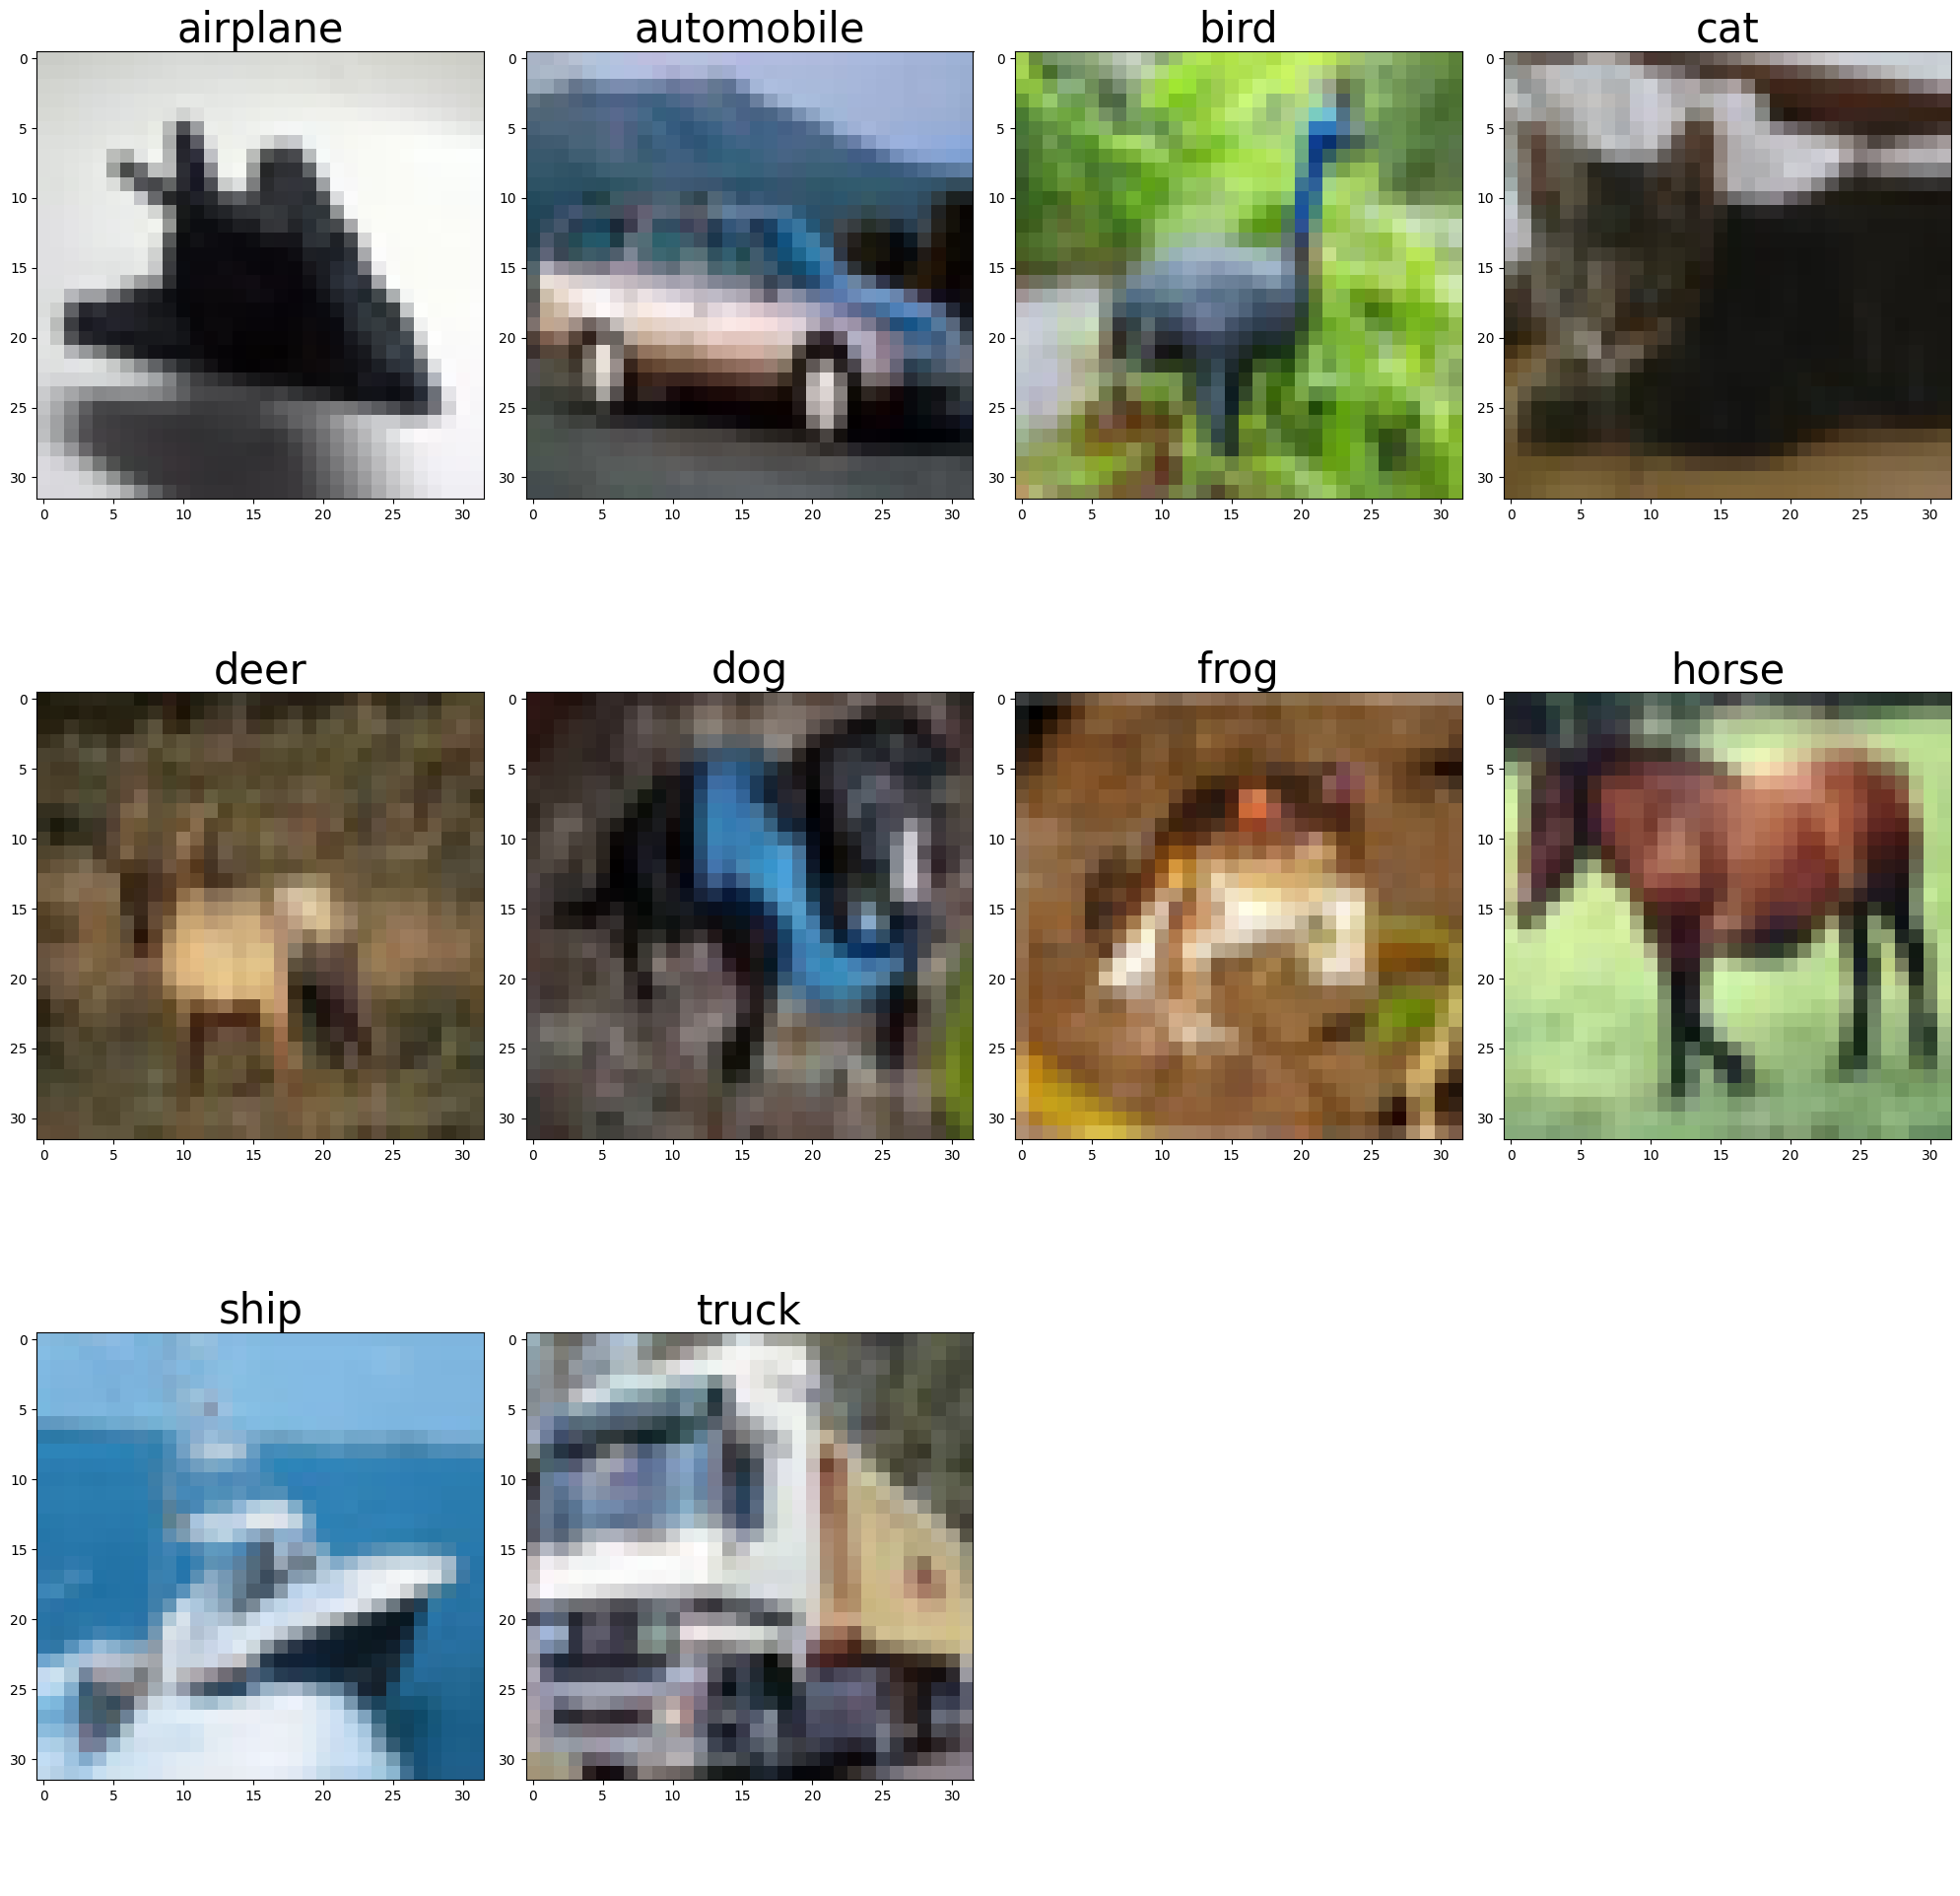

In [6]:
fig, axs = plt.subplots(3,4, figsize=(20,20))

for i in range(len(labels)):
    axs[i // 4, i%4].imshow(images[i])
    axs[i // 4, i%4].set_title(labels[i], fontsize=30)

for i in range(len(labels), 3*4):
    axs[i // 4, i%4].axis('off')

plt.tight_layout()
plt.show()

Conversion des images en niveaux de gris

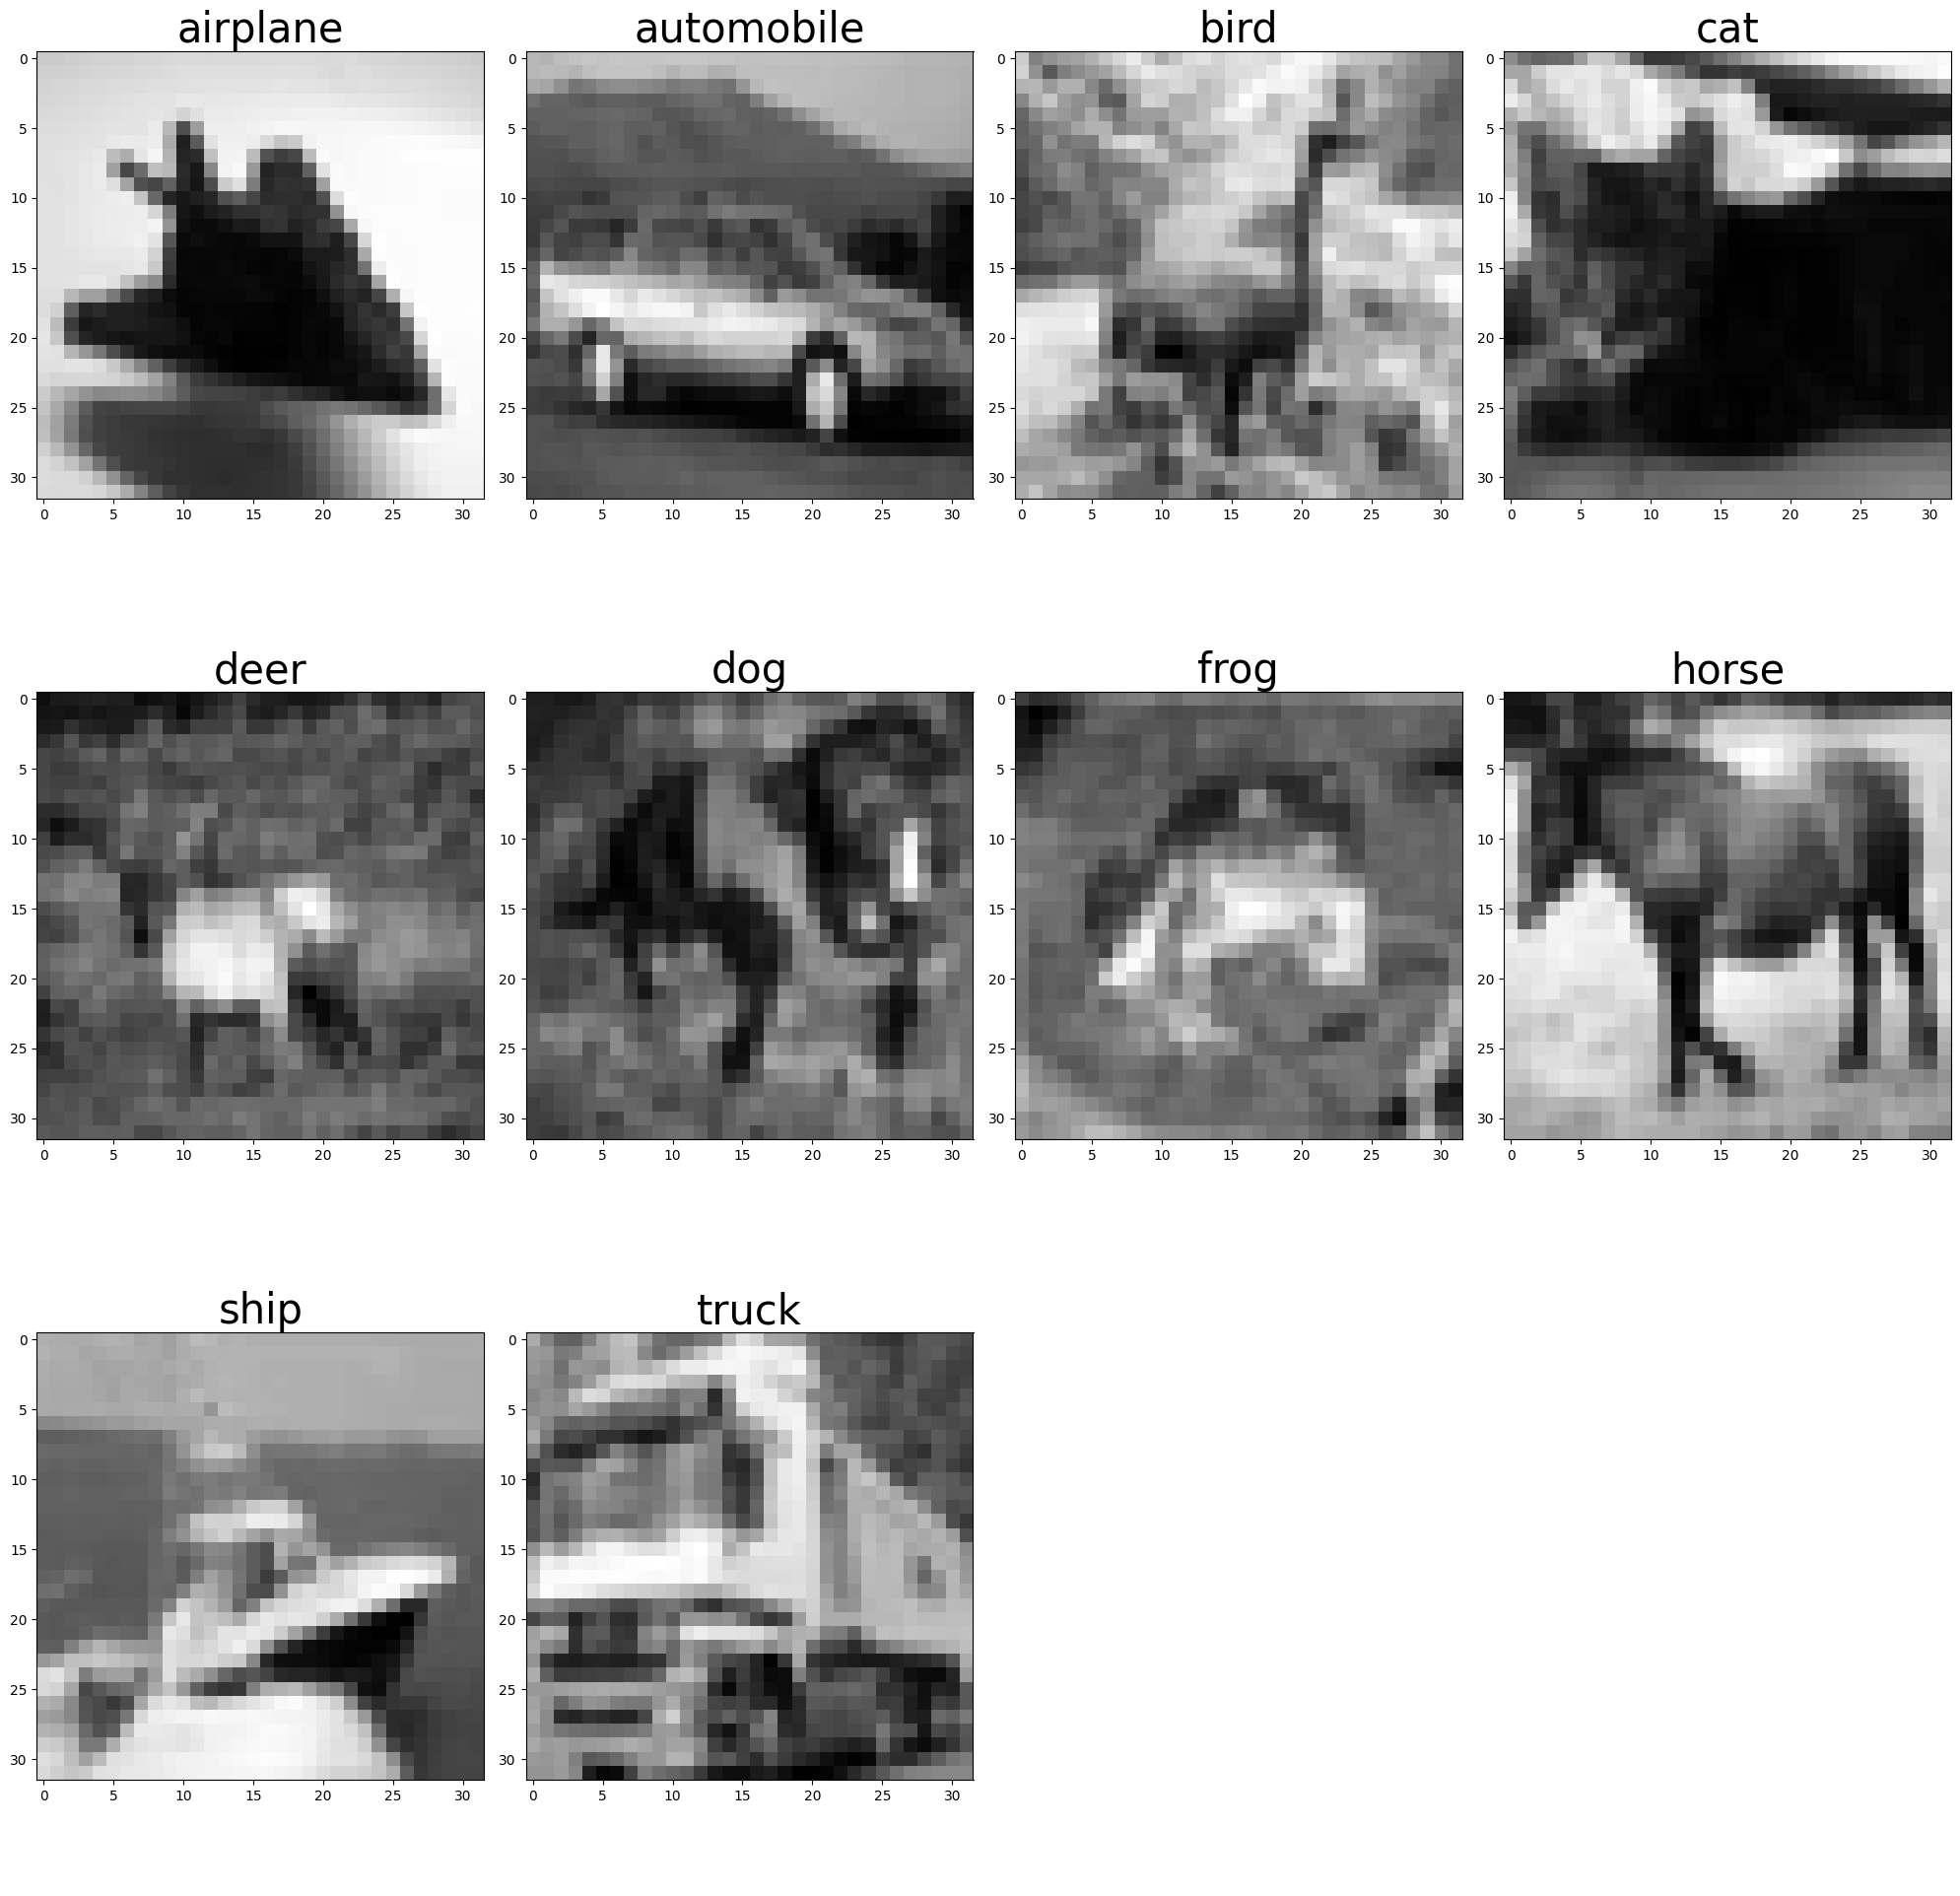

In [7]:
fig, axs = plt.subplots(3,4, figsize=(20,20))

for i in range(len(labels)):
    axs[i // 4, i%4].imshow(images[i].convert("L"),  cmap=plt.get_cmap('gray'))
    axs[i // 4, i%4].set_title(labels[i], fontsize=30)

for i in range(len(labels), 3*4):
    axs[i // 4, i%4].axis('off')

plt.tight_layout()
plt.show()

### Exploration Partie II

In [8]:
data = torchaudio.datasets.SPEECHCOMMANDS(download=True, root="./")
print("Nombre d'échantillon : ", data.__len__())

Nombre d'échantillon :  105829


Le dataset propose des ensembles préétablis pour l'entraînement, la validation et le test.

In [9]:
data_train = torchaudio.datasets.SPEECHCOMMANDS(download=True, root="./", subset="training")
data_validation = torchaudio.datasets.SPEECHCOMMANDS(download=True, root="./", subset="validation")
data_testing = torchaudio.datasets.SPEECHCOMMANDS(download=True, root="./", subset="testing")

print("Nombre d'échantillon d'entrainement : ", data_train.__len__())
print("Nombre d'échantillon de validation : ", data_validation.__len__())
print("Nombre d'échantillon de test : ", data_testing.__len__())

Nombre d'échantillon d'entrainement :  84843
Nombre d'échantillon de validation :  9981
Nombre d'échantillon de test :  11005


Récupération des labels du dataset

In [10]:

labels = os.listdir("./SpeechCommands/speech_commands_v0.02/")

labels.remove("README.md")
labels.remove("LICENSE")
labels.remove("testing_list.txt")
labels.remove("validation_list.txt")
labels.remove("_background_noise_")
labels.remove(".DS_Store")

print("Il y a  : ", len(labels), " labels")
print(labels)

Il y a  :  35  labels
['right', 'eight', 'tree', 'go', 'wow', 'happy', 'cat', 'dog', 'forward', 'bed', 'backward', 'zero', 'off', 'yes', 'learn', 'five', 'seven', 'sheila', 'left', 'nine', 'on', 'bird', 'no', 'follow', 'six', 'one', 'down', 'house', 'two', 'four', 'up', 'visual', 'stop', 'three', 'marvin']


Affichage de la distribution des échantillons dans chaque ensemble (entraînement, validation, test)

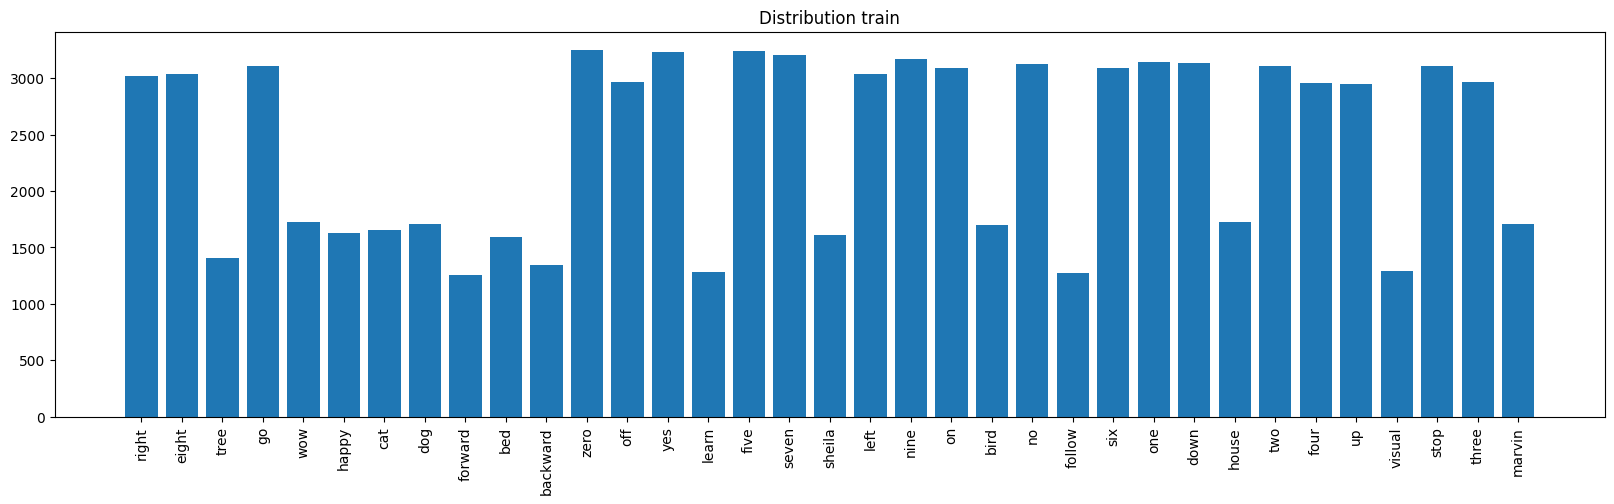

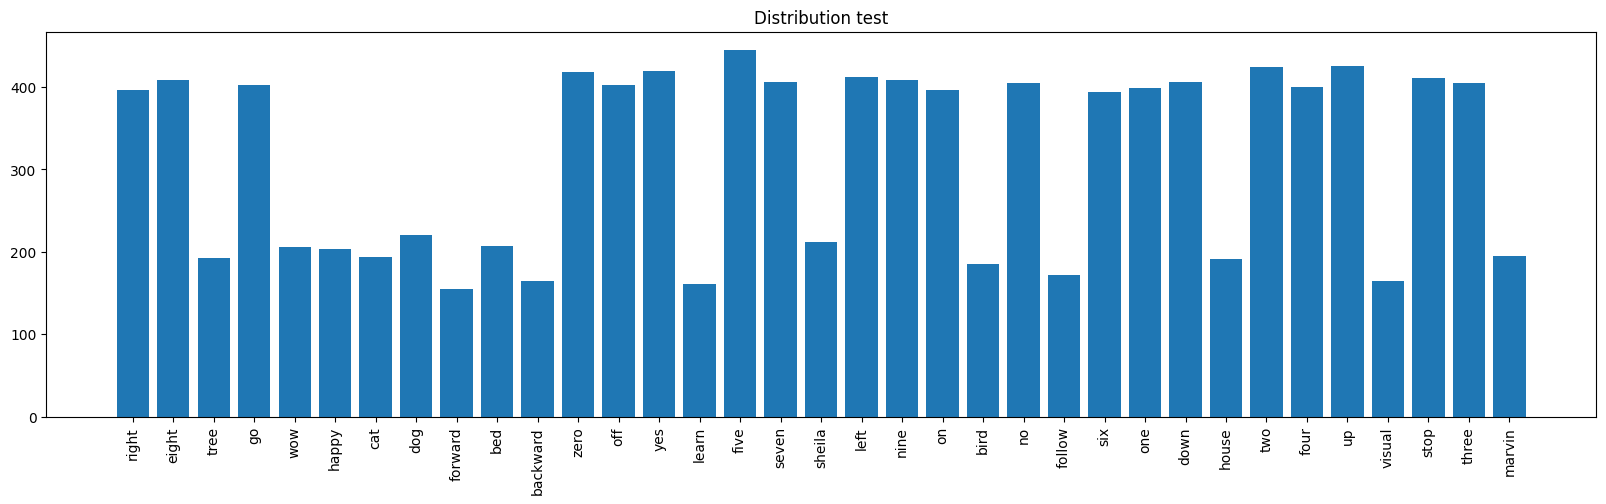

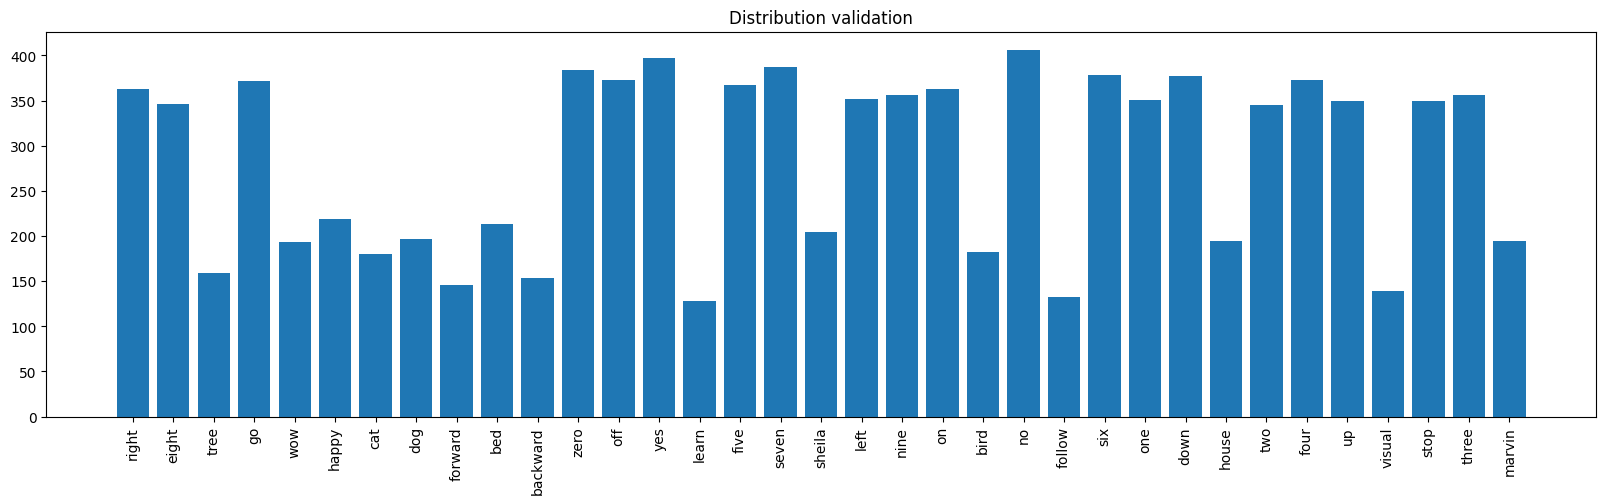

In [ ]:
import matplotlib.pyplot as plt

def distribution_dataset(dataset, name):
    count = [0 for i in range(len(labels))]

    for i in range(dataset.__len__()):
        count[labels.index(dataset.__getitem__(i)[2])] += 1
    
    plt.figure(figsize=(20,5))
    plt.xticks(rotation=90)
    plt.title(f"Distribution {name}")
    plt.bar(labels, count)
    plt.show()

distribution_dataset(data_train, "train")
distribution_dataset(data_testing, "test")
distribution_dataset(data_validation, "validation")

Récupération d'un échantillon audio par label pour visualisation

In [14]:
count = [0 for i in range(len(labels))]
sample = [[] for i in range(len(labels))]

for i in range(data_validation.__len__()):
    item = data_validation.__getitem__(i)
    index = labels.index(item[2])
    if count[index] == 0:
        sample[index] = item[0]
        count[index] = 1
    if sum(count) == 35:
        break
    

Affichage des waveforms des échantillons audio

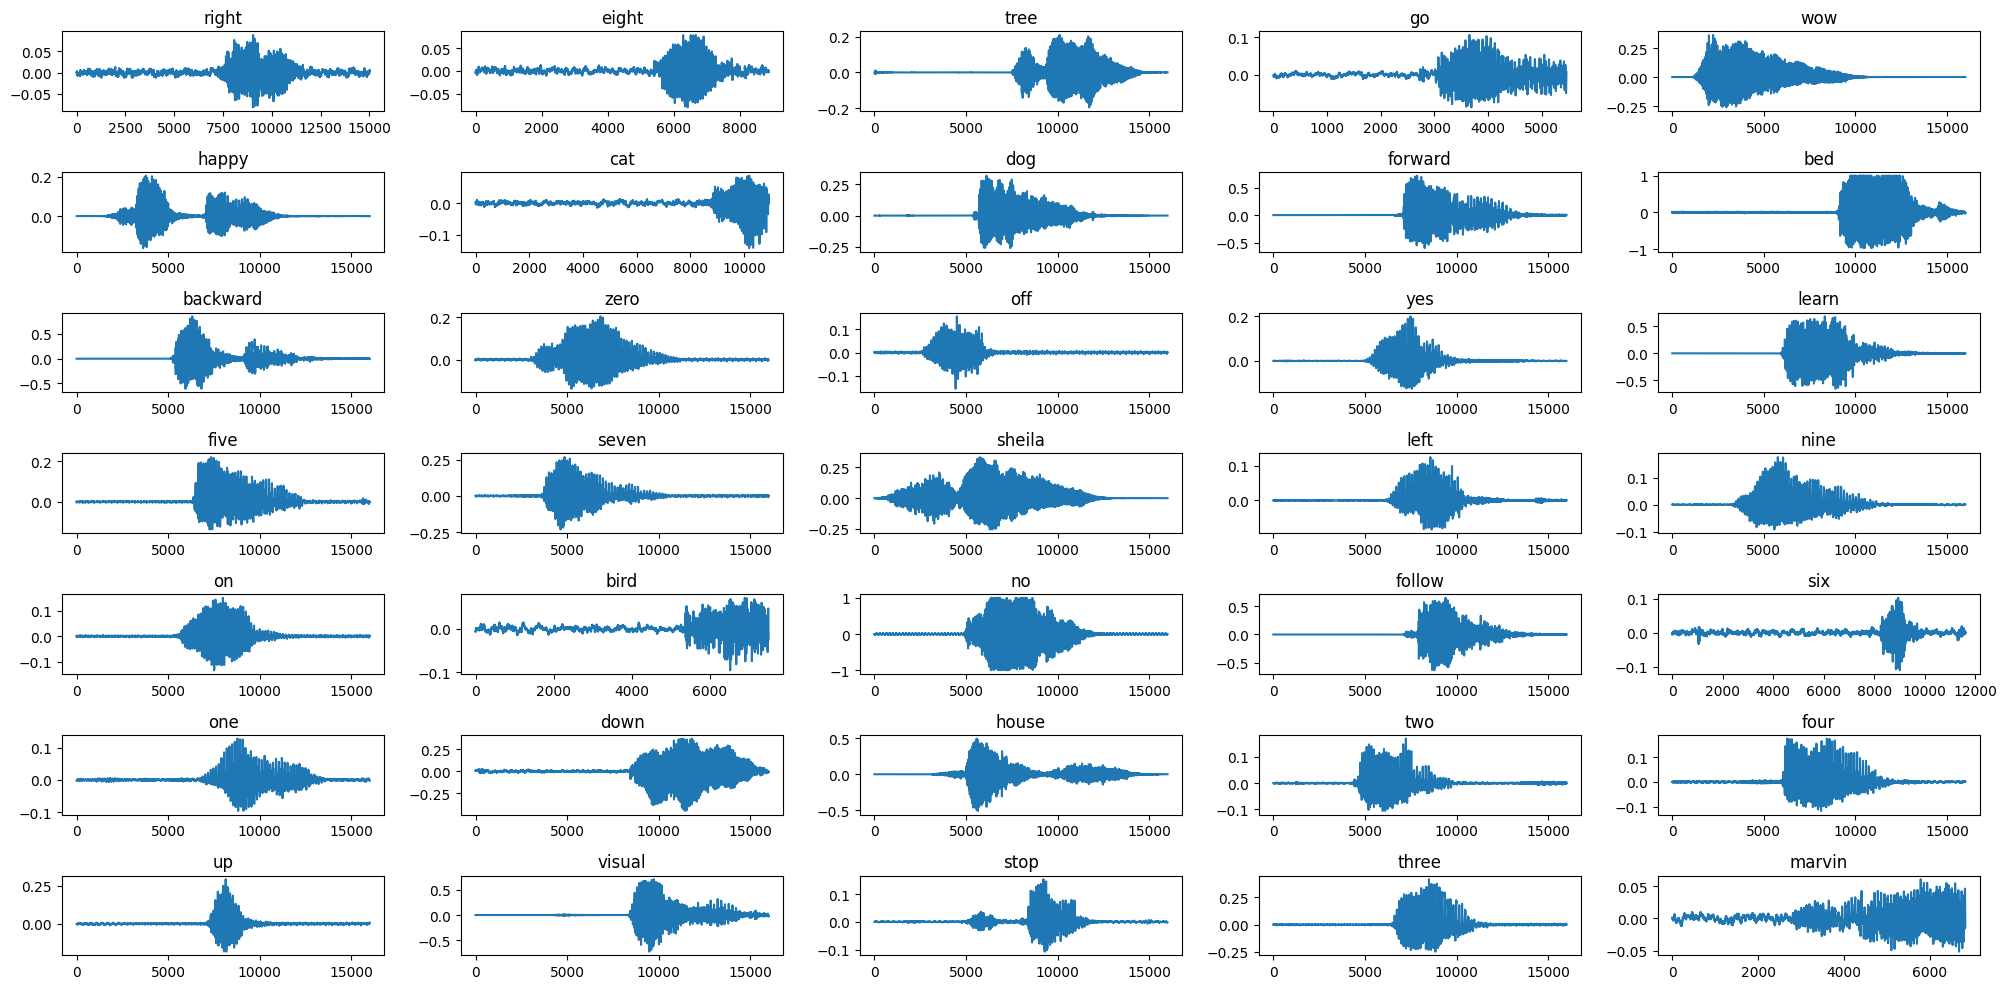

In [15]:
fig, axs = plt.subplots(7,5, figsize=(20,10))

for i in range(len(sample)):
    axs[i // 5, i%5].set_title(labels[i])
    axs[i // 5, i%5].plot(sample[i][0])

plt.tight_layout()
plt.show()

Affichage des MelSpectrogrammes des échantillons audio

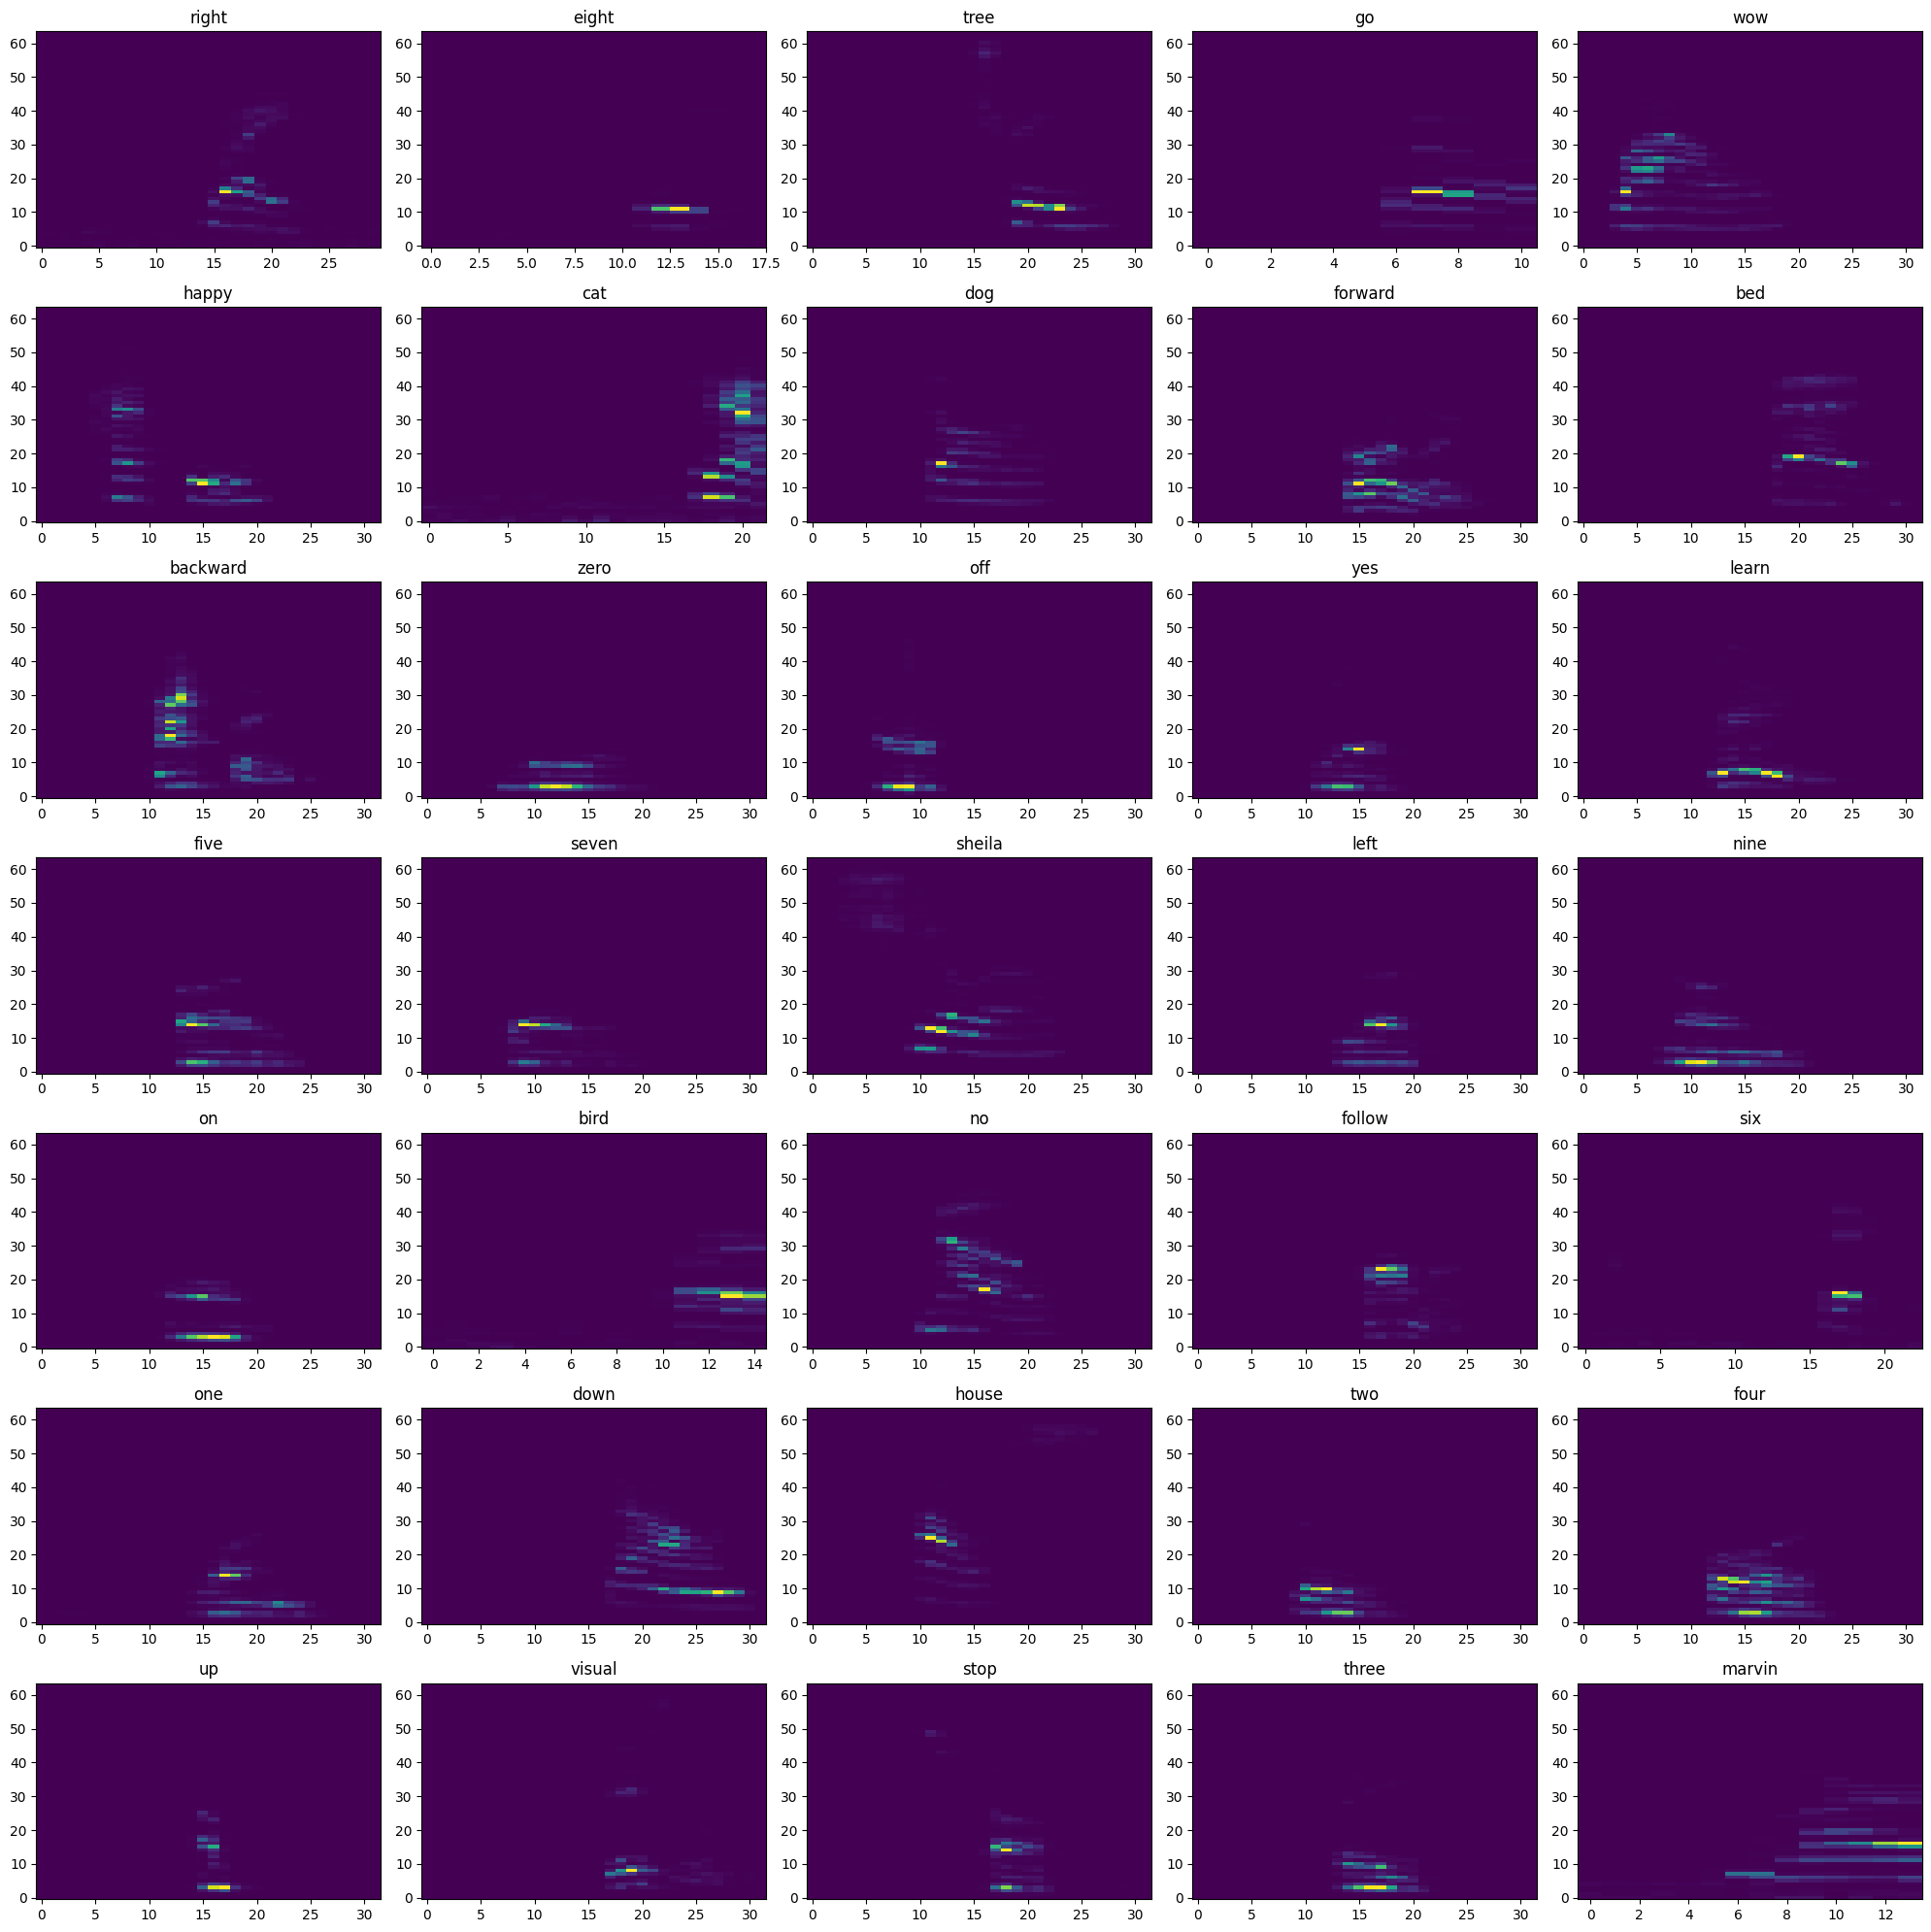

In [16]:
fig, axs = plt.subplots(7,5, figsize=(20,20))
transform = T.MelSpectrogram(n_fft=1024, sample_rate=16000, n_mels=64, hop_length=512)

for i in range(len(sample)):
    spectrogram = transform(sample[i][0])
    axs[i // 5, i%5].imshow(spectrogram.numpy(), origin="lower", aspect="auto", interpolation="nearest")
    axs[i // 5, i%5].set_title(labels[i])

plt.tight_layout()
plt.show()

Application d'une transformation logarithmique aux MelSpectrogrammes

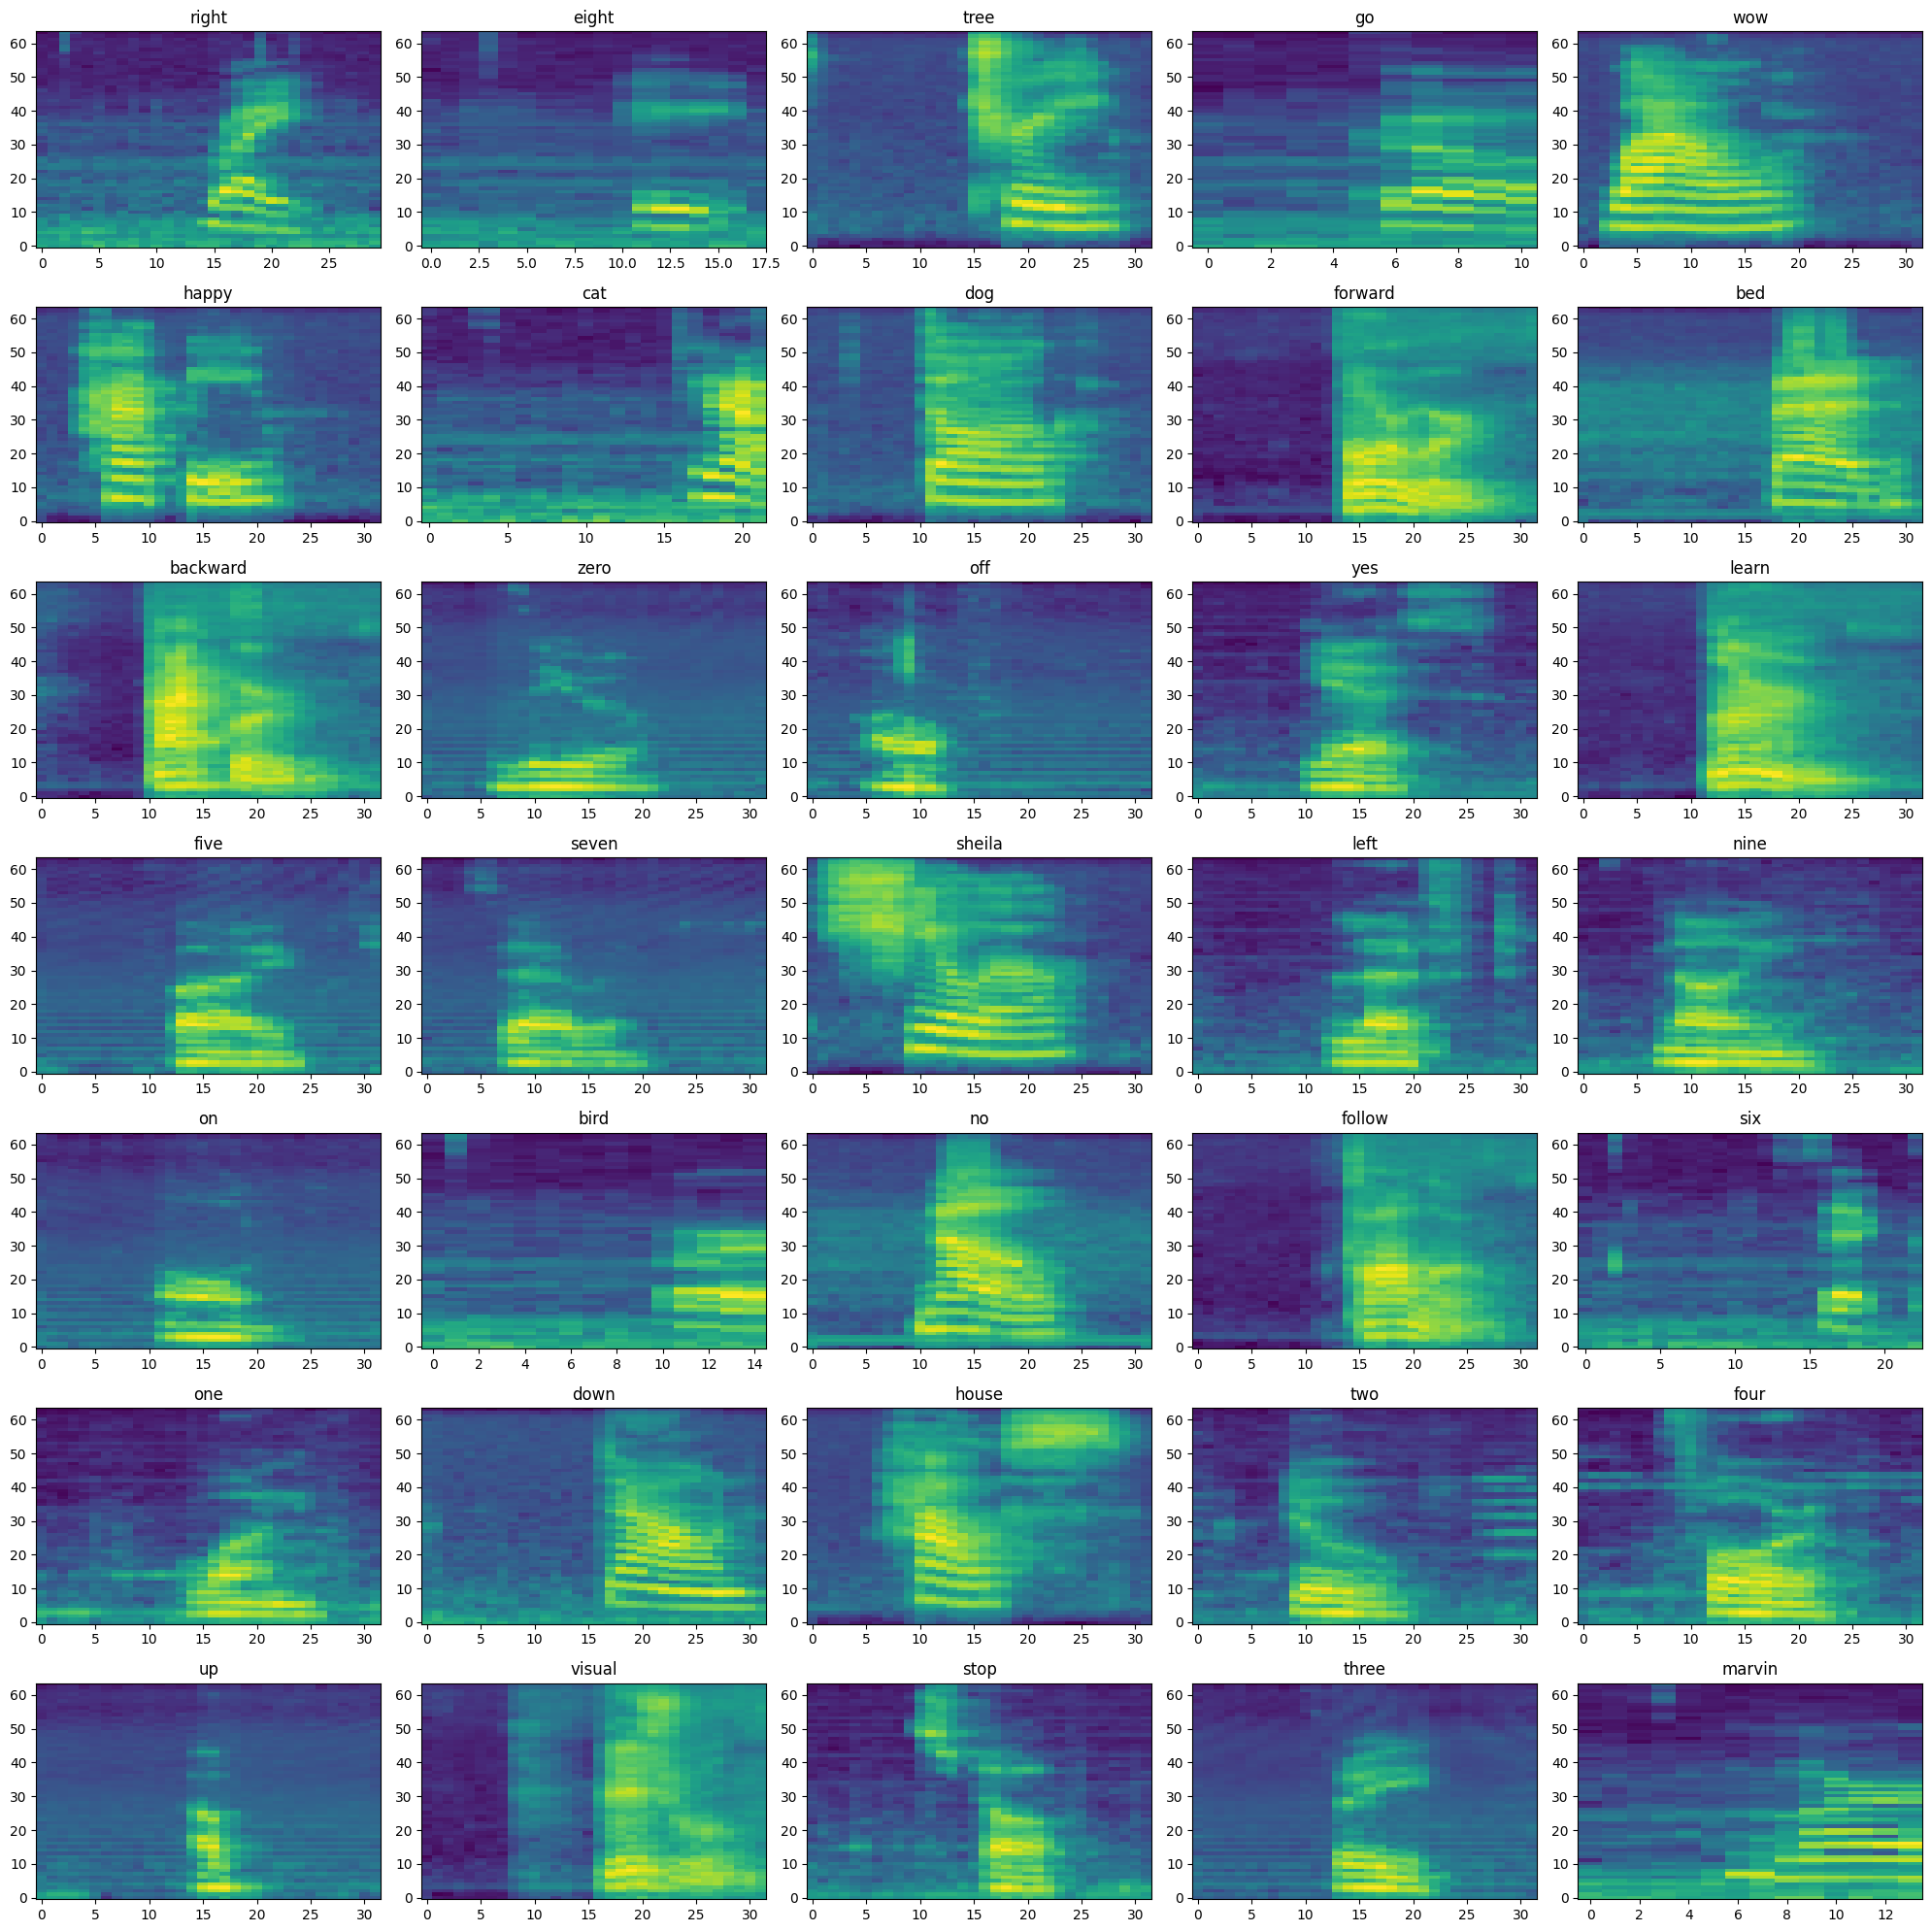

In [17]:
fig, axs = plt.subplots(7,5, figsize=(20,20))
transform = T.MelSpectrogram(n_fft=1024, sample_rate=16000, n_mels=64, hop_length=512)

for i in range(len(sample)):
    spectrogram = transform(sample[i][0])
    log_mel = torch.log(spectrogram + 1e-10)
    axs[i // 5, i%5].imshow(log_mel.numpy(), origin="lower", aspect="auto", interpolation="nearest")
    axs[i // 5, i%5].set_title(labels[i])

plt.tight_layout()
plt.show()

Vérification de la longueur et du taux d'échantillonnage des fichiers audio

In [20]:
irregulier_longueur_count = 0
irregulier_samplerate_count = 0
irregulier_grand_count = 0
irregulier_petit_count = 0

for i in data:
    if i[1] != 16000: irregulier_samplerate_count += 1
    if len(i[0][0]) != 16000: irregulier_longueur_count += 1
    if len(i[0][0])  < 16000: irregulier_petit_count += 1
    if len(i[0][0])  > 16000: irregulier_grand_count += 1

print("Irregulier plus grand que 1s : " + str(irregulier_grand_count))
print("Irregulier plus petit que 1s : " + str(irregulier_petit_count))

print("Irregulier samplerate : " + str(irregulier_samplerate_count))
print("Irregulier longueur : " + str(irregulier_longueur_count))

Irregulier plus grand que 1s : 0
Irregulier plus petit que 1s : 10435
Irregulier samplerate : 0
Irregulier longueur : 10435


Tous les fichiers ont le même taux d'échantillonnage (16 kHz).<br>
La plupart des fichiers n'ont pas la même durée.
Tous les segments sont plus courts que la durée maximale (1 seconde). Nous allons donc ajouter du silence à la fin des fichiers audio pour uniformiser leur longueur. (voir le script training_CNNModule.py pour l'implémentation)
